# Model 2C, Support Vector Machine Experiment 01

This append-only experiment compares linear and nonlinear support vector machines for Model 2C. It holds Logistic Regression 2C Experiment 02's selected representation fixed: 31 raw-taxi source fields plus a fold-fitted spline of `MINUTES_TO_SCHEDULED_ARRIVAL = CRSElapsedTime - DepDelay - TaxiOut`.

The linear candidate uses the prepared predictors directly. The nonlinear candidate uses random Fourier features to approximate an RBF kernel on the full training dataset, followed by the same linear SVM optimizer. This avoids the quadratic scaling of an exact RBF SVM while retaining a controlled nonlinear comparison.

Kernel family, regularization, and class weighting are selected using five expanding 2019 folds. A sigmoid calibration map and the operating threshold are learned only from held-out 2019 scores. The selected design is refitted on all 2019 rows and evaluated once on 2023. No new feature dataset is created, and the 2024 dataset is not loaded.


In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Memory
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler
from sklearn.svm import LinearSVC

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"
RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 1
SPLINE_KNOTS = 5
SPLINE_DEGREE = 3
RBF_COMPONENTS = 256

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Load and validate the shared arrival datasets

The experiment uses the same 2019 training rows and 2023 validation rows as the completed Model 2C experiments.


In [2]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve(), AIRPORT, [TRAIN_YEAR, VALIDATION_YEAR])
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Hold the selected Model 2C representation fixed

All 31 source fields and the degree-3 schedule-margin spline match Logistic Regression 2C Experiment 02. The experiment changes the classifier and, for the nonlinear candidates, adds a temporary RBF approximation inside the model pipeline.


In [3]:
CATEGORICAL_FEATURES = ["Reporting_Airline", "Origin"]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]
NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "TaxiOut",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL"
SOURCE_FEATURES = [*CATEGORICAL_FEATURES, *NUMERIC_FEATURES]
MODEL_COLUMNS = [*SOURCE_FEATURES, CALCULATED_MARGIN]

assert len(SOURCE_FEATURES) == len(set(SOURCE_FEATURES)) == 31
assert len(MODEL_COLUMNS) == 32

required_columns = ["FlightDate", "Dest", "CRSDepTime", TARGET, *SOURCE_FEATURES]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "WheelsOff",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(SOURCE_FEATURES)

pd.Series({
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "model inputs before preprocessing": len(MODEL_COLUMNS),
    "categorical source fields": len(CATEGORICAL_FEATURES),
    "numeric source fields": len(NUMERIC_FEATURES),
}, name="SVM 2C input design").to_frame()


,SVM 2C input design
saved source fields,31
calculated model-side fields,1
model inputs before preprocessing,32
categorical source fields,2
numeric source fields,29


## Calculate the margin and create chronological folds

The row-level margin uses only information known at takeoff. Every learned transformation is fitted separately inside each 2019 training fold.


In [4]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype(object)
    for column in NUMERIC_FEATURES:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame[CALCULATED_MARGIN] = (
        frame["CRSElapsedTime"] - frame["DepDelay"] - frame["TaxiOut"]
    )
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train = train_model_df[MODEL_COLUMNS].reset_index(drop=True)
X_validation = validation_model_df[MODEL_COLUMNS].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert X_train[CALCULATED_MARGIN].notna().all()
assert X_validation[CALCULATED_MARGIN].notna().all()


def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates, y_train, N_TIME_SPLITS
)
display(pd.DataFrame({
    "training": X_train[CALCULATED_MARGIN].describe(),
    "external_validation": X_validation[CALCULATED_MARGIN].describe(),
}))
fold_summary

,training,external_validation
count,"107,354.0000","109,947.0000"
mean,178.5130,165.9134
std,113.4119,117.9957
min,"-1,392.0000","-2,266.0000"
25%,97.0000,94.0000
50%,161.0000,148.0000
75%,288.0000,264.0000
max,578.0000,601.0000


,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Select kernel family, regularization, and class weighting using 2019

The linear candidates compare four regularization strengths with and without balanced class weights. The approximate RBF candidates compare three kernel widths, three regularization strengths, and the same two weighting choices. Random Fourier features are learned inside each training fold. Mean temporal average precision selects the configuration.


In [5]:
def make_pipeline(memory=None):
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    margin_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "spline",
            SplineTransformer(
                n_knots=SPLINE_KNOTS,
                degree=SPLINE_DEGREE,
                knots="quantile",
                extrapolation="linear",
                include_bias=False,
            ),
        ),
        ("scaler", StandardScaler()),
    ])
    preprocessor = ColumnTransformer(
        [
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("schedule_margin", margin_pipeline, [CALCULATED_MARGIN]),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )
    classifier = LinearSVC(
        penalty="l2",
        loss="squared_hinge",
        dual=False,
        max_iter=20_000,
        random_state=RANDOM_STATE,
    )
    return Pipeline(
        [
            ("preprocessor", preprocessor),
            ("kernel", "passthrough"),
            ("classifier", classifier),
        ],
        memory=memory,
    )


parameter_grid = [
    {
        "kernel": ["passthrough"],
        "classifier__C": [0.001, 0.01, 0.1, 1.0],
        "classifier__class_weight": [None, "balanced"],
    },
    {
        "kernel": [
            RBFSampler(
                n_components=RBF_COMPONENTS,
                random_state=RANDOM_STATE,
            )
        ],
        "kernel__gamma": [0.001, 0.01, 0.1],
        "classifier__C": [0.01, 0.1, 1.0],
        "classifier__class_weight": [None, "balanced"],
    },
]
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
}

search_start = perf_counter()
with TemporaryDirectory(prefix="svm_2c_", dir=PROJECT_ROOT / "tmp") as cache_dir:
    search = GridSearchCV(
        estimator=make_pipeline(memory=Memory(cache_dir, verbose=0)),
        param_grid=parameter_grid,
        scoring=scoring,
        refit="average_precision",
        cv=temporal_splits,
        n_jobs=N_JOBS,
        pre_dispatch=N_JOBS,
        verbose=0,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_
    best_pipeline.set_params(memory=None)

search_seconds = perf_counter() - search_start
search_results = pd.DataFrame(search.cv_results_)
search_results["kernel_family"] = search_results["param_kernel"].map(
    lambda value: "linear" if value == "passthrough" else "rbf_approximation"
)

display_columns = [
    "kernel_family",
    "param_kernel__gamma",
    "param_classifier__C",
    "param_classifier__class_weight",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_f1",
    "mean_fit_time",
]
ranked_search_results = (
    search_results[display_columns]
    .sort_values(
        ["mean_test_average_precision", "mean_test_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

selected_kernel = (
    "linear"
    if best_pipeline.named_steps["kernel"] == "passthrough"
    else "rbf_approximation"
)
print(f"SVM search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {search.best_score_:.4f}")
print(f"Selected kernel family: {selected_kernel}")
print(f"Selected parameters: {search.best_params_}")
ranked_search_results.head(15)


SVM search completed in 160.0 seconds
Best mean temporal-validation AP: 0.9077
Selected kernel family: linear
Selected parameters: {'classifier__C': 0.001, 'classifier__class_weight': None, 'kernel': 'passthrough'}


,kernel_family,param_kernel__gamma,param_classifier__C,param_classifier__class_weight,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_test_f1,mean_fit_time
0,linear,NaN,0.0010,NaN,0.9077,0.0176,0.9529,0.8054,0.4874
1,linear,NaN,0.0010,balanced,0.9065,0.0186,0.9530,0.7967,0.3666
2,linear,NaN,0.0100,NaN,0.9046,0.0228,0.9509,0.8032,0.6069
3,linear,NaN,0.0100,balanced,0.9041,0.0233,0.9511,0.7757,0.6044
4,linear,NaN,0.1000,NaN,0.9032,0.0259,0.9502,0.8024,0.8705
5,linear,NaN,1.0000,NaN,0.9027,0.0269,0.9498,0.8023,1.1158
6,linear,NaN,0.1000,balanced,0.9026,0.0261,0.9501,0.7702,0.8792
7,rbf_approximation,0.0010,1.0000,NaN,0.9024,0.0197,0.9505,0.7994,1.7983
8,rbf_approximation,0.0010,1.0000,balanced,0.9023,0.0208,0.9513,0.7890,2.2991
9,linear,NaN,1.0000,balanced,0.9021,0.0271,0.9497,0.7690,1.3258


## Calibrate scores and select the operating threshold using 2019 only

The selected SVM is refitted once per chronological fold to produce held-out 2019 decision scores. A two-parameter sigmoid map converts those scores to probabilities. The exact thresholds returned by the 2019 precision–recall curve are ranked by F1, with precision as the tie-breaker. Neither calibration nor threshold selection uses 2023.


In [6]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_scores = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = clone(best_pipeline)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    oof_scores[heldout_idx] = fold_model.decision_function(
        X_train.iloc[heldout_idx]
    )

oof_mask = np.isfinite(oof_scores)
oof_y = y_train.to_numpy()[oof_mask]
oof_s = oof_scores[oof_mask]
calibrator = LogisticRegression(
    C=1_000.0,
    solver="lbfgs",
    max_iter=2_000,
    random_state=RANDOM_STATE,
)
calibrator.fit(oof_s.reshape(-1, 1), oof_y)
oof_probabilities = calibrator.predict_proba(oof_s.reshape(-1, 1))[:, 1]

curve_precision, curve_recall, curve_thresholds = precision_recall_curve(
    oof_y, oof_probabilities
)
threshold_results = pd.DataFrame({
    "threshold": curve_thresholds,
    "precision": curve_precision[:-1],
    "recall": curve_recall[:-1],
})
threshold_results["f1"] = np.divide(
    2 * threshold_results["precision"] * threshold_results["recall"],
    threshold_results["precision"] + threshold_results["recall"],
    out=np.zeros(len(threshold_results)),
    where=(
        threshold_results["precision"] + threshold_results["recall"]
    ).to_numpy() > 0,
)
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "precision"], ascending=False
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only sigmoid slope: {calibrator.coef_[0, 0]:.6f}")
print(f"Training-only sigmoid intercept: {calibrator.intercept_[0]:.6f}")
print(f"Training-only selected threshold: {selected_threshold:.6f}")
threshold_results.sort_values(
    ["f1", "precision"], ascending=False
).head(10)


Threshold-selection rows: 89,578
Training-only sigmoid slope: 4.134987
Training-only sigmoid intercept: 0.440485
Training-only selected threshold: 0.428646


,threshold,precision,recall,f1
73728,0.4286,0.8838,0.7747,0.8257
73725,0.4282,0.8837,0.7748,0.8257
73691,0.4256,0.8827,0.7755,0.8257
73727,0.4285,0.8838,0.7747,0.8257
73693,0.4257,0.8828,0.7755,0.8257
73688,0.4255,0.8826,0.7756,0.8257
73700,0.4261,0.8830,0.7753,0.8257
73683,0.4251,0.8825,0.7757,0.8257
73729,0.4288,0.8838,0.7747,0.8257
73695,0.4259,0.8828,0.7754,0.8256


## Refit the selected SVM on 2019 and evaluate 2023

Only the SVM configuration, sigmoid calibration, and threshold selected from 2019 are evaluated on 2023. Logistic Regression 2C-02 is a fixed documented comparison and is not refitted here.


In [7]:
final_fit_start = perf_counter()
best_pipeline.fit(X_train, y_train)
final_fit_seconds = perf_counter() - final_fit_start
validation_scores = best_pipeline.decision_function(X_validation)
validation_probabilities = calibrator.predict_proba(
    validation_scores.reshape(-1, 1)
)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2C-02 (documented)",
        "threshold": 0.45,
        "accuracy": 0.9239,
        "balanced_accuracy": 0.8712,
        "precision": 0.9098,
        "recall": 0.7672,
        "f1": 0.8324,
        "mcc": 0.7885,
        "roc_auc": 0.9491,
        "average_precision": 0.9145,
        "brier_score": 0.0594,
    },
    {
        "model": "SVM 2C-01 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "SVM 2C-01 (training-selected)",
        **evaluate_probabilities(
            y_validation, validation_probabilities, selected_threshold
        ),
    },
]).set_index("model")

print(f"Final all-2019 fit completed in {final_fit_seconds:,.1f} seconds")
evaluation_results


Final all-2019 fit completed in 1.0 seconds


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2C-02 (documented),0.4500,0.9239,0.8712,0.9098,0.7672,0.8324,0.7885,0.9491,0.9145,0.0594
SVM 2C-01 (default),0.5000,0.9228,0.8667,0.9159,0.7560,0.8283,0.7851,0.9473,0.9116,0.0604
SVM 2C-01 (training-selected),0.4286,0.9224,0.8736,0.8937,0.7774,0.8315,0.7846,0.9473,0.9116,0.0604


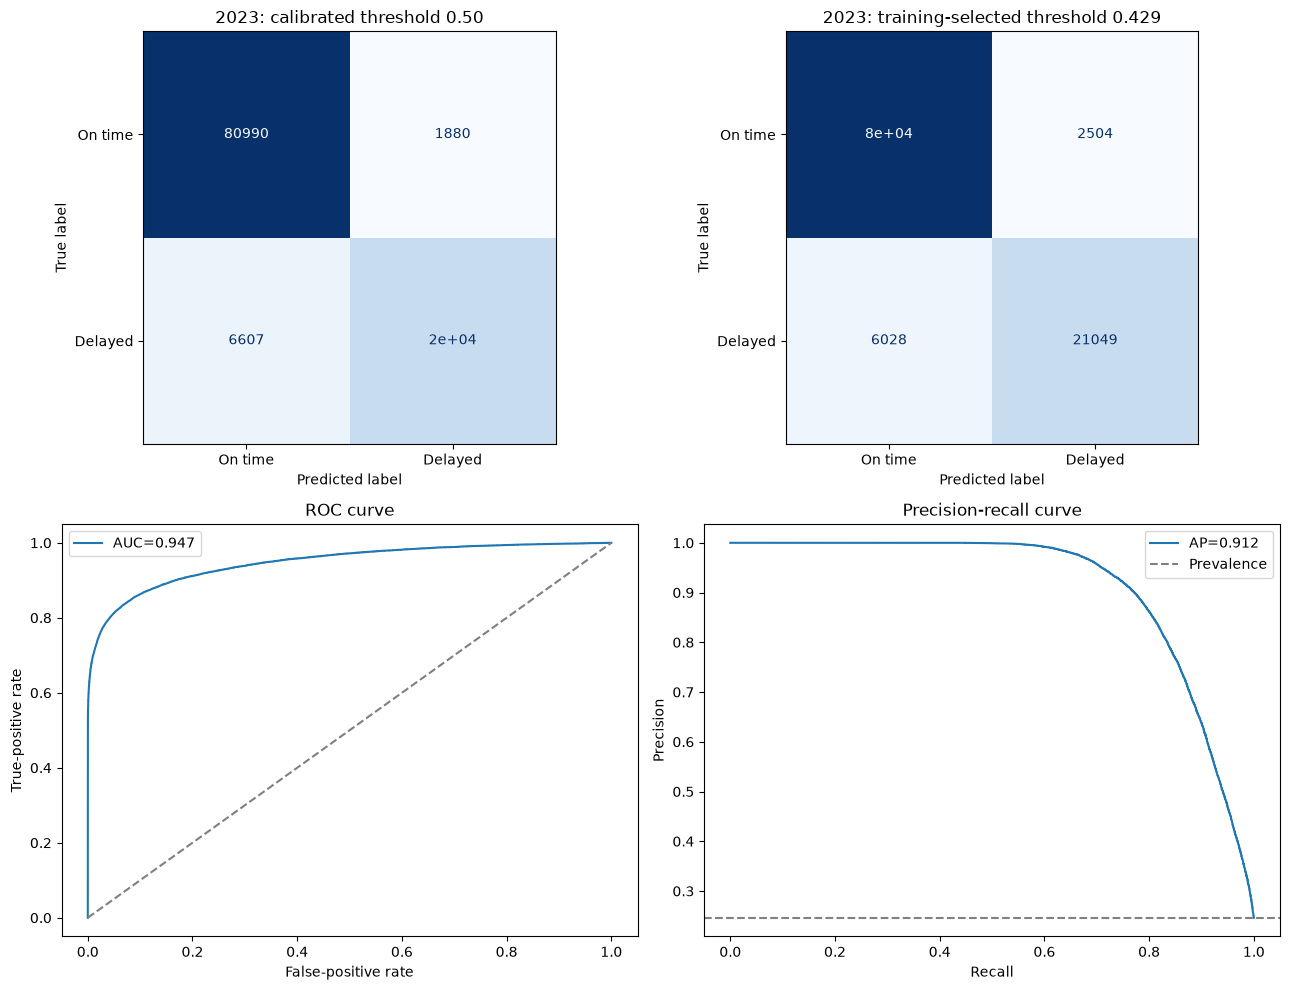

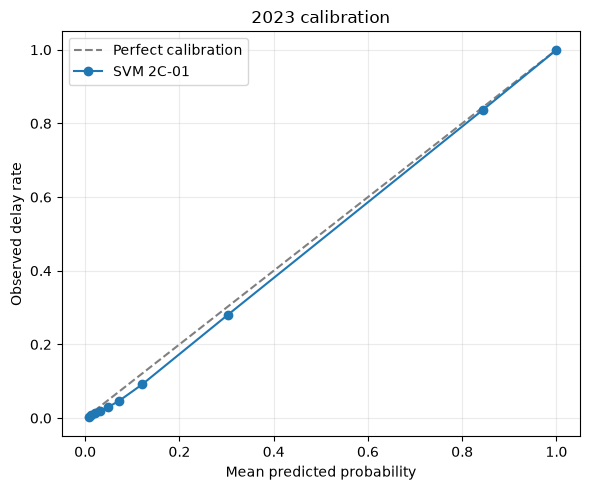

In [8]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: calibrated threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    f"2023: training-selected threshold {selected_threshold:.3f}"
)
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(), linestyle="--", color="gray", label="Prevalence"
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile"
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="SVM 2C-01")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Inspect the selected kernel and publishable values

The kernel comparison is the main interpretation. If the linear candidate wins, the maximum-margin boundary does not need the added RBF representation. If the RBF approximation wins, the fixed 256 random Fourier components provide a scalable nonlinear mapping, not a directly interpretable feature-importance table.


In [9]:
preprocessor = best_pipeline.named_steps["preprocessor"]
prepared_feature_names = preprocessor.get_feature_names_out()
kernel_step = best_pipeline.named_steps["kernel"]
classifier = best_pipeline.named_steps["classifier"]
classifier_inputs = (
    len(prepared_feature_names)
    if kernel_step == "passthrough"
    else kernel_step.n_components
)
selected_gamma = None if kernel_step == "passthrough" else kernel_step.gamma

display(pd.DataFrame({
    "partition": ["held-out 2019", "2023 validation"],
    "minimum_probability": [oof_probabilities.min(), validation_probabilities.min()],
    "median_probability": [np.median(oof_probabilities), np.median(validation_probabilities)],
    "mean_probability": [oof_probabilities.mean(), validation_probabilities.mean()],
    "maximum_probability": [oof_probabilities.max(), validation_probabilities.max()],
    "observed_delay_rate": [oof_y.mean(), y_validation.mean()],
}).set_index("partition"))

default = evaluation_results.loc["SVM 2C-01 (default)"]
selected = evaluation_results.loc["SVM 2C-01 (training-selected)"]
publishable_summary = pd.Series({
    "selected representation": "raw_taxi_margin_spline",
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "prepared predictors": len(prepared_feature_names),
    "selected kernel family": selected_kernel,
    "classifier inputs": classifier_inputs,
    "selected RBF gamma": selected_gamma,
    "RBF components when applicable": RBF_COMPONENTS,
    "selected C": search.best_params_["classifier__C"],
    "selected class weighting": str(
        search.best_params_["classifier__class_weight"]
    ),
    "training CV AP": search.best_score_,
    "sigmoid slope": calibrator.coef_[0, 0],
    "sigmoid intercept": calibrator.intercept_[0],
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="SVM 2C Experiment 01 Appendix F values")
publishable_summary.to_frame()


,minimum_probability,median_probability,mean_probability,maximum_probability,observed_delay_rate
partition,,,,,
held-out 2019,0.0002,0.0366,0.2019,1.0000,0.2019
2023 validation,0.0001,0.0357,0.2330,1.0000,0.2463


,SVM 2C Experiment 01 Appendix F values
selected representation,raw_taxi_margin_spline
saved source fields,31
calculated model-side fields,1
prepared predictors,108
selected kernel family,linear
classifier inputs,108
selected RBF gamma,None
RBF components when applicable,256
selected C,0.0010
selected class weighting,None


## Interpretation checklist

1. Does the linear or approximate RBF kernel win the 2019 temporal comparison?
2. Does the selected SVM improve 2019 average precision over Logistic Regression 2C Experiment 02?
3. Does any training gain persist in 2023 ranking, probability quality, F1, or MCC?
4. Does sigmoid calibration produce usable probabilities?
5. Is the difference large enough to replace the sparse L1 model?
6. Keep the existing feature dataset unchanged and keep 2024 untouched.
